In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

query = """
SELECT uid, timestamp, numTrials
FROM checker
WHERE uid LIKE 'user_%'
AND labname='project1'
AND status='ready'
"""

df = pd.read_sql(query, conn, parse_dates='timestamp')
conn.close()

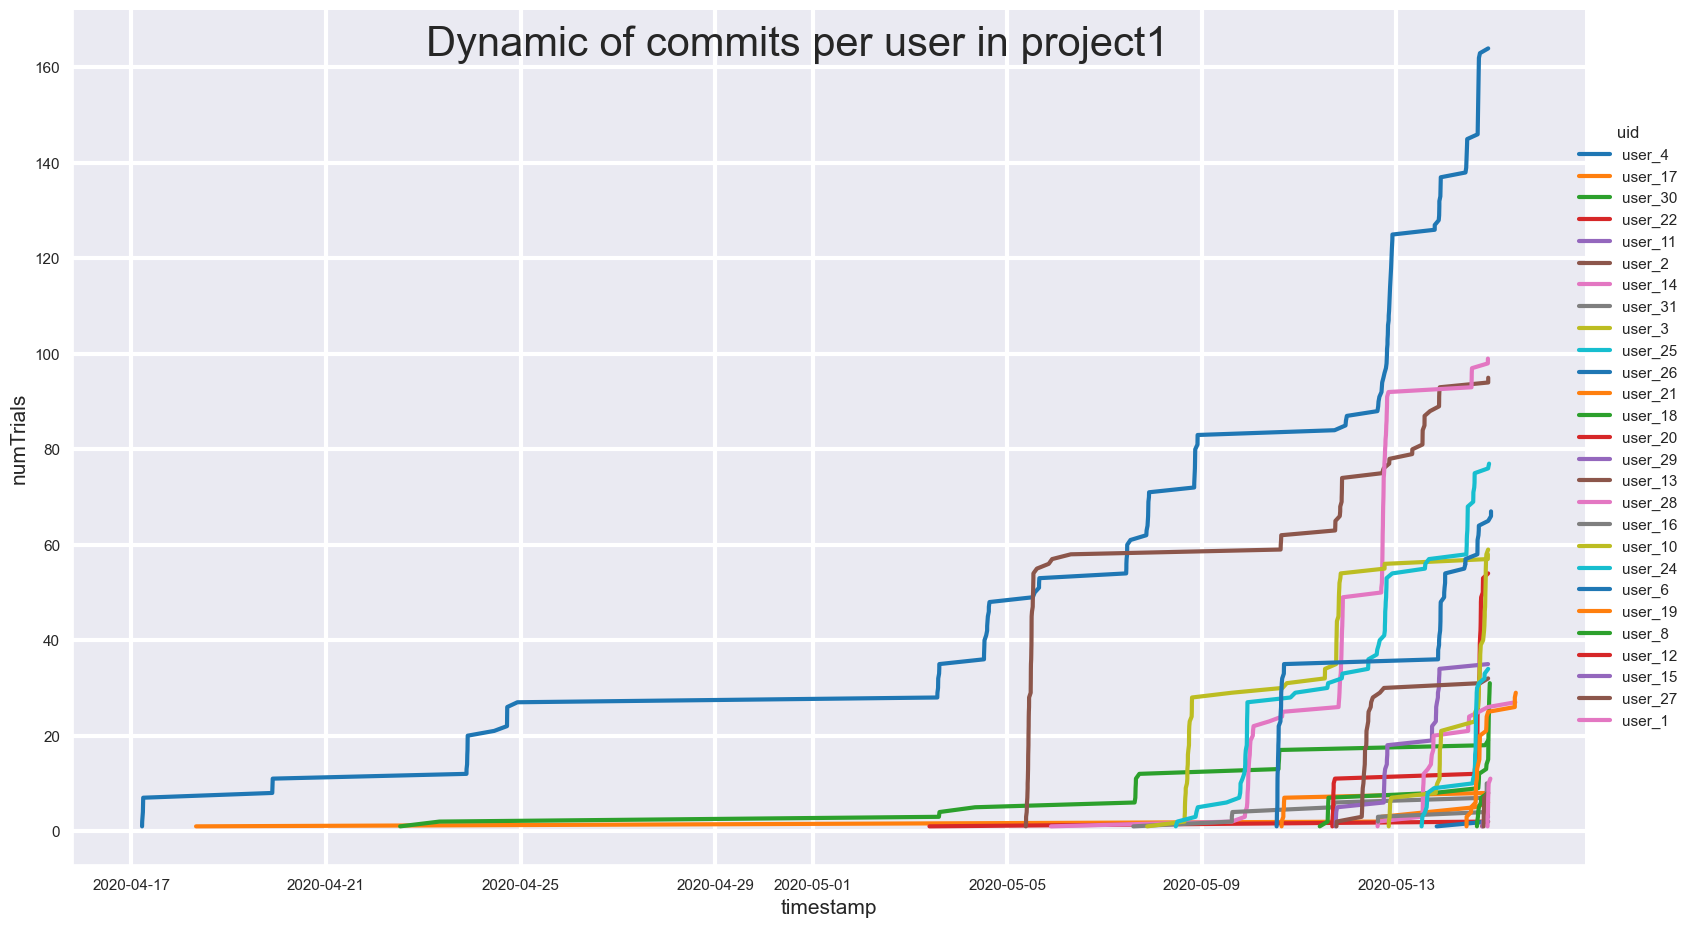

In [21]:
sns.set_style("dark")

g = sns.relplot(
    data=df,
    x="timestamp",
    y="numTrials",
    hue="uid",
    kind="line",
    height=10,
    aspect=1.5,
    linewidth=3,
    palette="tab10",
    sort=True,
    markers=True
)

g.ax.grid(True, linewidth=3)
g.ax.set_xlabel("timestamp", fontsize=15)
g.ax.set_ylabel("numTrials", fontsize=15)
g.legend.set_bbox_to_anchor((1.05, 0.5))
g.legend.set_title("uid")

g.figure.suptitle("Dynamic of commits per user in project1", fontsize=30, y=0.91)

plt.tight_layout()
plt.show()

Q. Which user was the leader in the number of commits almost all of the time?
The answer is user_4.

Q. Which user was the leader for only a short period of time?
The answer is user_2.